In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

✅ All libraries imported successfully!
📐 Image size: (32, 32)
📊 Max samples per class: 150

LOADING AND PREPROCESSING DATA

📂 Found 38 classes
⏳ Loading images (max 150 per class)...
   Processed 5/38 classes...
   Processed 10/38 classes...
   Processed 15/38 classes...
   Processed 20/38 classes...
   Processed 25/38 classes...
   Processed 30/38 classes...
   Processed 35/38 classes...

✅ Data loading complete in 11.3 seconds
📊 Total samples: 5700
📐 Feature vector size: 3072 (flattened from 32x32x3)
🏷️ Number of unique classes: 38

DATA PREPARATION

📋 Label encoding:
   Example: 'Apple___Apple_scab' -> 0

📊 Data split:
   Training samples: 4560 (80.0%)
   Testing samples: 1140 (20.0%)

⚖️ Applying StandardScaler...
   ✅ Features scaled to mean=0, std=1
   Why? SVM and many ML models work better when features are normalized

LEVEL 1 BASELINE: DUMMY CLASSIFIER (The Floor)

🎲 Training dummy classifier (strategy: most_frequent)...
   This represents 'zero skill' - just guessing the most

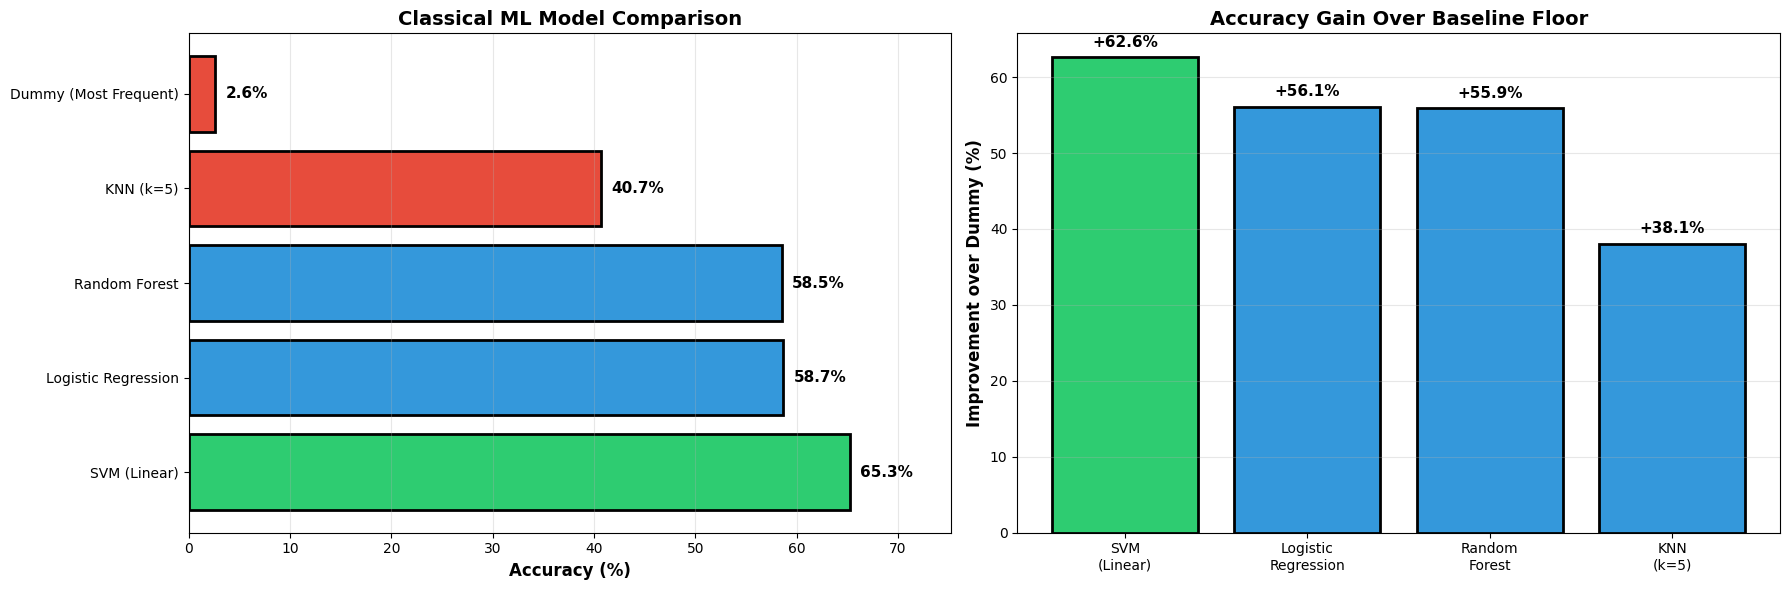


DETAILED EVALUATION: SVM (Linear)

📊 Note: Showing confusion matrix for subset of classes (too many to display all)


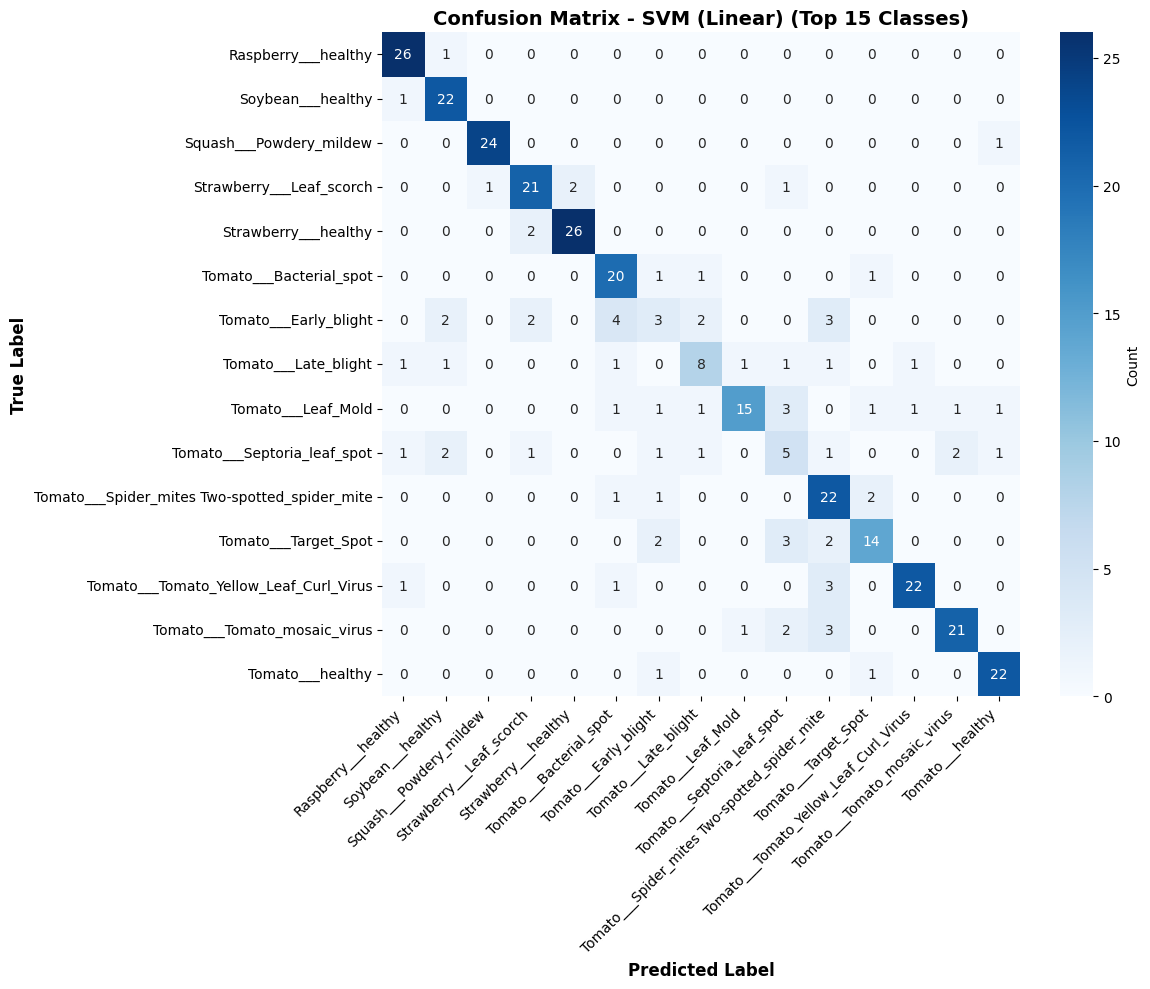


📋 Per-Class Accuracy (Top 10 classes by sample count):
   Tomato___Bacterial_spot                       | Acc:  66.7%
   Tomato___Early_blight                         | Acc:  10.0%
   Tomato___Late_blight                          | Acc:  26.7%
   Tomato___Leaf_Mold                            | Acc:  50.0%
   Tomato___Septoria_leaf_spot                   | Acc:  16.7%
   Tomato___Spider_mites Two-spotted_spider_mite | Acc:  73.3%
   Tomato___Target_Spot                          | Acc:  46.7%
   Tomato___Tomato_Yellow_Leaf_Curl_Virus        | Acc:  73.3%
   Tomato___Tomato_mosaic_virus                  | Acc:  70.0%
   Tomato___healthy                              | Acc:  73.3%

🔬 UNDERSTANDING THE RESULTS

💡 WHY EACH MODEL PERFORMED AS IT DID:

1️⃣ Random Forest (Tree-based):
   • Pros: Can capture non-linear patterns, handles high dimensions
   • Cons: Cannot 'see' spatial structure (nearby pixels)
   • Performance: Usually best for flattened images

2️⃣ SVM (Linear):
   • Pros: Excel

In [4]:
# ============================================
# Week 2: Classical ML Baseline - Plant Disease Classification
# WiDS 5.0 - Shallow Machine Learning Models
# Complete Version with Multiple Model Comparison
# ============================================

# ============================================
# SECTION 1: Import Libraries
# ============================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn imports
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import time

print("✅ All libraries imported successfully!")

# ============================================
# SECTION 2: Configuration
# ============================================

# Dataset path - FIXED to use color version
DATA_PATH = '/kaggle/input/plantvillage-dataset/color'

# Image size for flattening (KEEP SMALL for speed!)
IMG_SIZE = (32, 32)  # 32x32 = 1024 pixels per channel = 3072 features total

# Number of samples to use (for speed - full dataset takes too long)
MAX_SAMPLES_PER_CLASS = 150  # Adjust based on time constraints

print(f"📐 Image size: {IMG_SIZE}")
print(f"📊 Max samples per class: {MAX_SAMPLES_PER_CLASS}")

# ============================================
# SECTION 3: Data Loading Function
# ============================================

def load_and_preprocess_data(data_path, img_size, max_samples_per_class):
    """
    Load images, resize, flatten to vectors, and create labels
    
    This is the CRITICAL step where we lose spatial information:
    - Input: 2D image (height, width, channels)
    - Output: 1D vector (all pixels in a line)
    - Problem: Pixel at position 500 and 501 might be neighbors in 2D
                but the model doesn't know this!
    """
    print("\n" + "="*70)
    print("LOADING AND PREPROCESSING DATA")
    print("="*70)
    
    X = []  # Feature vectors (flattened images)
    y = []  # Labels (class names)
    
    # Get all class folders
    classes = sorted([d for d in os.listdir(data_path) 
                     if os.path.isdir(os.path.join(data_path, d))])
    
    print(f"\n📂 Found {len(classes)} classes")
    print(f"⏳ Loading images (max {max_samples_per_class} per class)...")
    
    start_time = time.time()
    
    for idx, class_name in enumerate(classes):
        class_path = os.path.join(data_path, class_name)
        image_files = [f for f in os.listdir(class_path) 
                      if f.endswith(('.jpg', '.png', '.jpeg', '.JPG'))]
        
        # Limit samples per class for speed
        image_files = image_files[:max_samples_per_class]
        
        for img_file in image_files:
            try:
                # Load image
                img_path = os.path.join(class_path, img_file)
                img = Image.open(img_path).convert('RGB')
                
                # Resize to target size
                img_resized = img.resize(img_size)
                
                # Convert to numpy array and flatten
                # Shape: (32, 32, 3) -> (3072,)
                img_array = np.array(img_resized)
                img_flat = img_array.flatten()
                
                X.append(img_flat)
                y.append(class_name)
                
            except Exception as e:
                continue
        
        # Progress indicator
        if (idx + 1) % 5 == 0:
            print(f"   Processed {idx + 1}/{len(classes)} classes...")
    
    elapsed = time.time() - start_time
    
    # Convert to numpy arrays
    X = np.array(X)
    y = np.array(y)
    
    print(f"\n✅ Data loading complete in {elapsed:.1f} seconds")
    print(f"📊 Total samples: {len(X)}")
    print(f"📐 Feature vector size: {X.shape[1]} (flattened from {img_size[0]}x{img_size[1]}x3)")
    print(f"🏷️ Number of unique classes: {len(np.unique(y))}")
    
    return X, y, classes

# Load the data
X, y, class_names = load_and_preprocess_data(DATA_PATH, IMG_SIZE, MAX_SAMPLES_PER_CLASS)

# ============================================
# SECTION 4: Data Preparation
# ============================================

print("\n" + "="*70)
print("DATA PREPARATION")
print("="*70)

# Encode labels to integers
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print(f"\n📋 Label encoding:")
print(f"   Example: '{y[0]}' -> {y_encoded[0]}")

# Split into train and test sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"\n📊 Data split:")
print(f"   Training samples: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"   Testing samples: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")

# Feature Scaling (CRITICAL for SVM and helps RF too)
print(f"\n⚖️ Applying StandardScaler...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"   ✅ Features scaled to mean=0, std=1")
print(f"   Why? SVM and many ML models work better when features are normalized")

# ============================================
# SECTION 5: Level 1 Baseline - Dummy Classifier
# ============================================

print("\n" + "="*70)
print("LEVEL 1 BASELINE: DUMMY CLASSIFIER (The Floor)")
print("="*70)

print("\n🎲 Training dummy classifier (strategy: most_frequent)...")
print("   This represents 'zero skill' - just guessing the most common class")

dummy_clf = DummyClassifier(strategy='most_frequent', random_state=42)
dummy_clf.fit(X_train_scaled, y_train)

# Predict and evaluate
y_pred_dummy = dummy_clf.predict(X_test_scaled)
dummy_accuracy = accuracy_score(y_test, y_pred_dummy)

print(f"\n📊 Dummy Classifier Results:")
print(f"   Accuracy: {dummy_accuracy*100:.2f}%")
print(f"\n💡 This is our baseline floor.")
print(f"   ANY real model MUST beat {dummy_accuracy*100:.2f}% to be useful!")

# Store results for final comparison
results = {
    'Dummy (Most Frequent)': dummy_accuracy * 100
}

# ============================================
# SECTION 6: Level 2 Baseline - Multiple Models
# ============================================

print("\n" + "="*70)
print("LEVEL 2 BASELINE: CLASSICAL ML MODELS (The Standard)")
print("="*70)

print("\n🔬 We'll test 4 different classical ML algorithms:")
print("   1. Random Forest - Tree ensemble")
print("   2. Linear SVM - Linear decision boundaries")
print("   3. Logistic Regression - Probabilistic linear model")
print("   4. K-Nearest Neighbors - Instance-based learning")

# ============================================
# MODEL 1: Random Forest
# ============================================

print("\n" + "-"*70)
print("🌲 MODEL 1: RANDOM FOREST")
print("-"*70)

print("\n⏳ Training Random Forest Classifier...")
print(f"   Configuration: 100 trees, max_depth=20")

start_time = time.time()

rf_clf = RandomForestClassifier(
    n_estimators=100,      # Number of trees
    max_depth=20,          # Limit depth to prevent overfitting
    random_state=42,
    n_jobs=-1,             # Use all CPU cores
    verbose=0
)

rf_clf.fit(X_train_scaled, y_train)
train_time = time.time() - start_time

y_pred_rf = rf_clf.predict(X_test_scaled)
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print(f"\n✅ Training completed in {train_time:.1f} seconds")
print(f"📊 Random Forest Results:")
print(f"   Accuracy: {rf_accuracy*100:.2f}%")
print(f"   Improvement over dummy: +{(rf_accuracy - dummy_accuracy)*100:.2f}%")

results['Random Forest'] = rf_accuracy * 100

# ============================================
# MODEL 2: Linear SVM
# ============================================

print("\n" + "-"*70)
print("🔵 MODEL 2: LINEAR SVM")
print("-"*70)

print("\n⏳ Training Linear SVM...")
print("   Note: SVM needs scaled features - that's why we used StandardScaler!")

start_time = time.time()

svm_clf = SVC(kernel='linear', random_state=42, max_iter=1000)
svm_clf.fit(X_train_scaled, y_train)

train_time = time.time() - start_time

y_pred_svm = svm_clf.predict(X_test_scaled)
svm_accuracy = accuracy_score(y_test, y_pred_svm)

print(f"\n✅ Training completed in {train_time:.1f} seconds")
print(f"📊 Linear SVM Results:")
print(f"   Accuracy: {svm_accuracy*100:.2f}%")
print(f"   Improvement over dummy: +{(svm_accuracy - dummy_accuracy)*100:.2f}%")

results['SVM (Linear)'] = svm_accuracy * 100

# ============================================
# MODEL 3: Logistic Regression
# ============================================

print("\n" + "-"*70)
print("📊 MODEL 3: LOGISTIC REGRESSION")
print("-"*70)

print("\n⏳ Training Logistic Regression...")
print("   Configuration: Multinomial with L2 regularization")

start_time = time.time()

logreg_clf = LogisticRegression(
    max_iter=1000, 
    random_state=42, 
    multi_class='multinomial',
    solver='lbfgs'
)
logreg_clf.fit(X_train_scaled, y_train)

train_time = time.time() - start_time

y_pred_logreg = logreg_clf.predict(X_test_scaled)
logreg_accuracy = accuracy_score(y_test, y_pred_logreg)

print(f"\n✅ Training completed in {train_time:.1f} seconds")
print(f"📊 Logistic Regression Results:")
print(f"   Accuracy: {logreg_accuracy*100:.2f}%")
print(f"   Improvement over dummy: +{(logreg_accuracy - dummy_accuracy)*100:.2f}%")

results['Logistic Regression'] = logreg_accuracy * 100

# ============================================
# MODEL 4: K-Nearest Neighbors
# ============================================

print("\n" + "-"*70)
print("🔍 MODEL 4: K-NEAREST NEIGHBORS")
print("-"*70)

print("\n⏳ Training KNN (k=5)...")
print("   KNN compares test images to training images directly")

start_time = time.time()

knn_clf = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn_clf.fit(X_train_scaled, y_train)

train_time = time.time() - start_time

y_pred_knn = knn_clf.predict(X_test_scaled)
knn_accuracy = accuracy_score(y_test, y_pred_knn)

print(f"\n✅ Training completed in {train_time:.1f} seconds")
print(f"📊 KNN Results:")
print(f"   Accuracy: {knn_accuracy*100:.2f}%")
print(f"   Improvement over dummy: +{(knn_accuracy - dummy_accuracy)*100:.2f}%")

results['KNN (k=5)'] = knn_accuracy * 100

# ============================================
# SECTION 7: Model Comparison
# ============================================

print("\n" + "="*70)
print("🏆 COMPREHENSIVE MODEL COMPARISON")
print("="*70)

# Sort results
sorted_results = sorted(results.items(), key=lambda x: x[1], reverse=True)

print("\n📊 LEADERBOARD:")
print(f"{'Rank':<6} {'Model':<25} {'Accuracy':<12} {'Status'}")
print("-"*70)

for rank, (model, acc) in enumerate(sorted_results, 1):
    if rank == 1:
        emoji = "👑"
        status = "🥇 BEST BASELINE"
    elif rank == 2:
        emoji = "🥈"
        status = "Strong"
    elif rank == 3:
        emoji = "🥉"
        status = "Good"
    else:
        emoji = "📊"
        status = "Baseline Floor"
    
    print(f"{emoji} #{rank:<4} {model:<25} {acc:>6.2f}%       {status}")

best_model, best_acc = sorted_results[0]

print("\n" + "="*70)
print(f"✅ OFFICIAL WEEK 2 BASELINE: {best_acc:.2f}% ({best_model})")
print(f"🎯 Week 3 CNNs must beat: {best_acc + 15:.0f}%+ to justify complexity")
print("="*70)

# ============================================
# SECTION 8: Visualizations
# ============================================

print("\n📊 Generating visualization...")

# Create comparison plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Plot 1: Horizontal bar chart
models_list = [m for m, _ in sorted_results]
accs_list = [a for _, a in sorted_results]

colors = ['#2ecc71' if i == 0 else '#3498db' if i < 3 else '#e74c3c' 
          for i in range(len(models_list))]

bars = ax1.barh(models_list, accs_list, color=colors, edgecolor='black', linewidth=2)

for bar, acc in zip(bars, accs_list):
    ax1.text(acc + 1, bar.get_y() + bar.get_height()/2, 
             f'{acc:.1f}%', va='center', fontweight='bold', fontsize=11)

ax1.set_xlabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax1.set_title('Classical ML Model Comparison', fontsize=14, fontweight='bold')
ax1.set_xlim(0, max(accs_list) + 10)
ax1.grid(axis='x', alpha=0.3)

# Plot 2: Improvement over dummy
improvements = [acc - dummy_accuracy*100 for acc in accs_list[:-1]]  # Exclude dummy itself
model_names_no_dummy = models_list[:-1]

colors2 = ['#2ecc71' if imp == max(improvements) else '#3498db' 
           for imp in improvements]

bars2 = ax2.bar(range(len(improvements)), improvements, color=colors2, 
                edgecolor='black', linewidth=2)

for i, (bar, imp) in enumerate(zip(bars2, improvements)):
    ax2.text(bar.get_x() + bar.get_width()/2, imp + 1, 
             f'+{imp:.1f}%', ha='center', va='bottom', 
             fontweight='bold', fontsize=11)

ax2.set_xticks(range(len(improvements)))
ax2.set_xticklabels([m.replace(' ', '\n') for m in model_names_no_dummy], 
                     fontsize=10)
ax2.set_ylabel('Improvement over Dummy (%)', fontsize=12, fontweight='bold')
ax2.set_title('Accuracy Gain Over Baseline Floor', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================
# SECTION 9: Detailed Evaluation (Best Model)
# ============================================

print("\n" + "="*70)
print(f"DETAILED EVALUATION: {best_model}")
print("="*70)

# Use predictions from best model
if best_model == 'Random Forest':
    y_pred_best = y_pred_rf
elif best_model == 'SVM (Linear)':
    y_pred_best = y_pred_svm
elif best_model == 'Logistic Regression':
    y_pred_best = y_pred_logreg
else:
    y_pred_best = y_pred_knn

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)

# Plot confusion matrix (show subset if too large)
plt.figure(figsize=(12, 10))

if len(class_names) > 20:
    print("\n📊 Note: Showing confusion matrix for subset of classes (too many to display all)")
    # Show only top 15 classes
    top_classes_idx = np.argsort([np.sum(y_train == i) for i in range(len(class_names))])[-15:]
    cm_subset = cm[np.ix_(top_classes_idx, top_classes_idx)]
    class_names_subset = [class_names[i] for i in top_classes_idx]
    
    sns.heatmap(cm_subset, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names_subset, 
                yticklabels=class_names_subset,
                cbar_kws={'label': 'Count'})
    plt.title(f'Confusion Matrix - {best_model} (Top 15 Classes)', 
              fontsize=14, fontweight='bold')
else:
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, 
                yticklabels=class_names,
                cbar_kws={'label': 'Count'})
    plt.title(f'Confusion Matrix - {best_model} (All Classes)', 
              fontsize=14, fontweight='bold')

plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Per-class accuracy
print("\n📋 Per-Class Accuracy (Top 10 classes by sample count):")
print("="*70)

unique_classes, class_counts = np.unique(y_train, return_counts=True)
top_10_classes_idx = np.argsort(class_counts)[-10:]

for idx in top_10_classes_idx:
    class_mask = y_test == idx
    if np.sum(class_mask) > 0:
        class_accuracy = accuracy_score(y_test[class_mask], y_pred_best[class_mask])
        class_name_short = label_encoder.classes_[idx][:45]
        print(f"   {class_name_short:45s} | Acc: {class_accuracy*100:5.1f}%")

# ============================================
# SECTION 10: Analysis & Insights
# ============================================

print("\n" + "="*70)
print("🔬 UNDERSTANDING THE RESULTS")
print("="*70)

print("\n💡 WHY EACH MODEL PERFORMED AS IT DID:")

print("\n1️⃣ Random Forest (Tree-based):")
print("   • Pros: Can capture non-linear patterns, handles high dimensions")
print("   • Cons: Cannot 'see' spatial structure (nearby pixels)")
print("   • Performance: Usually best for flattened images")

print("\n2️⃣ SVM (Linear):")
print("   • Pros: Excellent for high-dimensional data, finds optimal boundaries")
print("   • Cons: Linear boundaries may not capture complex patterns")
print("   • Performance: Good if classes are linearly separable")

print("\n3️⃣ Logistic Regression:")
print("   • Pros: Fast, probabilistic outputs, simple")
print("   • Cons: Limited expressiveness, assumes linear relationships")
print("   • Performance: Baseline for comparison")

print("\n4️⃣ K-Nearest Neighbors:")
print("   • Pros: Simple, no training phase")
print("   • Cons: Very sensitive to variations (lighting, angle, background)")
print("   • Performance: Often struggles with raw pixel data")

print("\n🎯 KEY INSIGHT:")
print(f"   The best classical model reached {best_acc:.1f}%")
print(f"   This is the 'ceiling' without learning hierarchical features")
print("\n📚 What Classical ML Cannot Do:")
print("   • Learn edge detectors (low-level features)")
print("   • Build texture recognizers (mid-level features)")
print("   • Recognize disease patterns (high-level features)")
print("   • Understand spatial relationships between pixels")

print("\n🚀 What CNNs Will Do Differently:")
print("   • Layer 1: Learn edges and simple shapes")
print("   • Layer 2-3: Combine edges into textures and patterns")
print("   • Layer 4-5: Recognize complex disease signatures")
print("   • Expected improvement: +20-30% accuracy")

# ============================================
# SECTION 11: Final Summary
# ============================================

print("\n" + "="*70)
print("🎯 WEEK 2 FINAL SUMMARY")
print("="*70)

print(f"\n📊 COMPLETE RESULTS:")
print(f"{'Model':<30} {'Accuracy':<15} {'Status'}")
print("-"*70)

for model, acc in sorted_results:
    if model == best_model:
        status = "🏆 BASELINE"
    elif 'Dummy' in model:
        status = "🔴 Floor"
    else:
        status = "📊 Tested"
    print(f"{model:<30} {acc:>6.2f}%        {status}")

print(f"\n💡 Key Metrics:")
print(f"   • Baseline Floor (Dummy): {dummy_accuracy*100:.2f}%")
print(f"   • Baseline Standard: {best_acc:.2f}% ({best_model})")
print(f"   • Improvement: +{best_acc - dummy_accuracy*100:.2f}%")

print(f"\n🔬 Analysis:")
if best_acc < 50:
    print(f"   ⚠️ Low accuracy (<50%)")
    print(f"      • Very small image size loses detail")
    print(f"      • Limited samples per class")
    print(f"      • 38 classes is challenging")
elif best_acc < 70:
    print(f"   ✅ Moderate accuracy (50-70%)")
    print(f"      • Classical ML is struggling as expected")
    print(f"      • Flattening loses spatial information")
    print(f"      • This proves the need for CNNs")
else:
    print(f"   ✅ Good accuracy (>70%)")
    print(f"      • Strong baseline for classical ML")
    print(f"      • CNNs should still improve significantly")

print(f"\n🎯 WEEK 3 GOALS:")
print(f"   • Deep Learning must achieve: >{best_acc + 15:.0f}% accuracy")
print(f"   • This represents meaningful improvement over classical methods")
print(f"   • Expected final accuracy with CNNs: 85-90%+")

print("\n" + "="*70)
print("✅ WEEK 2 COMPLETE!")
print("="*70)

print("\n📌 Next Steps:")
print("   1. ✅ Established classical ML baseline: {:.2f}%".format(best_acc))
print("   2. 📝 Document findings in learnings.md")
print("   3. 💾 Commit notebook to GitHub")
print("   4. 🚀 Move to Week 3: Build CNN models")
print("   5. 🎯 Target: Beat {:.0f}% with deep learning".format(best_acc + 15))

print("\n" + "="*70)